In [1]:
import os
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connexion à la Base de Données (Interne à Docker)
# On utilise le nom du service 'mongodb' défini dans docker-compose
client = MongoClient("mongodb://mongodb:27017/")
db = client['thumalien_db']
collection = db['raw_posts']

# 2. Chargement des données dans un DataFrame Pandas
# On récupère tout (find({})) et on exclut l'ID technique mongo (_id: 0)
cursor = collection.find({}, {"_id": 0})
df = pd.DataFrame(list(cursor))

# 3. Affichage des premières infos
print(f"📊 Nombre total de posts récupérés : {len(df)}")
print("-" * 30)
display(df.head())

📊 Nombre total de posts récupérés : 3527
------------------------------


,uri,author_did,author_handle,cid,collected_at,created_at,search_term,text
0,at://did:plc:l2ycnbx3yrvz4tgyhey3lztg/app.bsky...,did:plc:l2ycnbx3yrvz4tgyhey3lztg,blakehamiltonca.bsky.social,bafyreib3pdxa5yft5ba7jofgpzw2qjt5hg3nbgmpiodc2...,2025-12-12 10:05:03.111,2025-12-11T21:58:59.502Z,climat,[5/6]\n\n4) Objectif climat : chaque tonne de ...
1,at://did:plc:36jpkeznunjdcr6fuoawmfx7/app.bsky...,did:plc:36jpkeznunjdcr6fuoawmfx7,eyeonthearctic.bsky.social,bafyreihkwmmblsmfuxyqynwdtjqkwlcedllwxsavg6fjl...,2025-12-12 10:05:03.111,2025-12-11T21:56:49.964Z,climat,Les scientifiques d’ECCC prévoient des #tempér...
2,at://did:plc:jiducmlejdii4fhktgwlfva3/app.bsky...,did:plc:jiducmlejdii4fhktgwlfva3,h24newsfr.bsky.social,bafyreifxb2tvp54h7v3vs7zfs7jx3qlc3vyizqbbrwlyk...,2025-12-12 10:05:03.111,2025-12-11T21:32:34.000Z,climat,"Vučić évoque un message de Moscou pour l'UE, u..."
3,at://did:plc:3fku6rbchamq3symzjznprwy/app.bsky...,did:plc:3fku6rbchamq3symzjznprwy,publicsenat.fr,bafyreibb2ccbqby3ogsfldylvgxeusxrbsei4jjxc3uok...,2025-12-12 10:05:03.111,2025-12-11T21:15:04.000Z,climat,Climat : « Si on n’agit pas pour des raisons a...
4,at://did:plc:64ya3hfliv42w2np5dojevlv/app.bsky...,did:plc:64ya3hfliv42w2np5dojevlv,patbonin.bsky.social,bafyreifxicjxgm6y75vfbrbr6xbwuzqp5wzmxefr7oq3o...,2025-12-12 10:05:03.111,2025-12-11T20:59:17.666Z,climat,"Le bilan générationnel des libéraux, c’est leu..."


⚠️ Nombre de doublons potentiels : 0


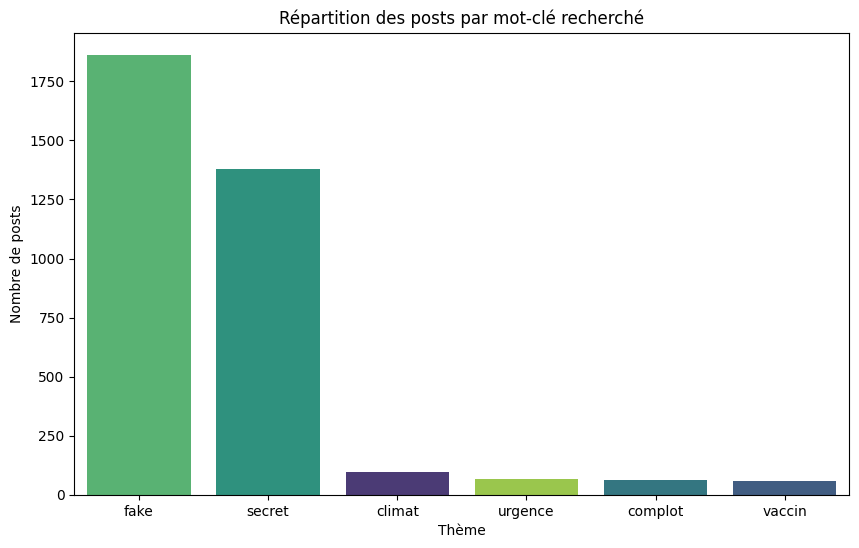

Type de la colonne : datetime64[ns, UTC]
Dates valides : 3527 / 3527


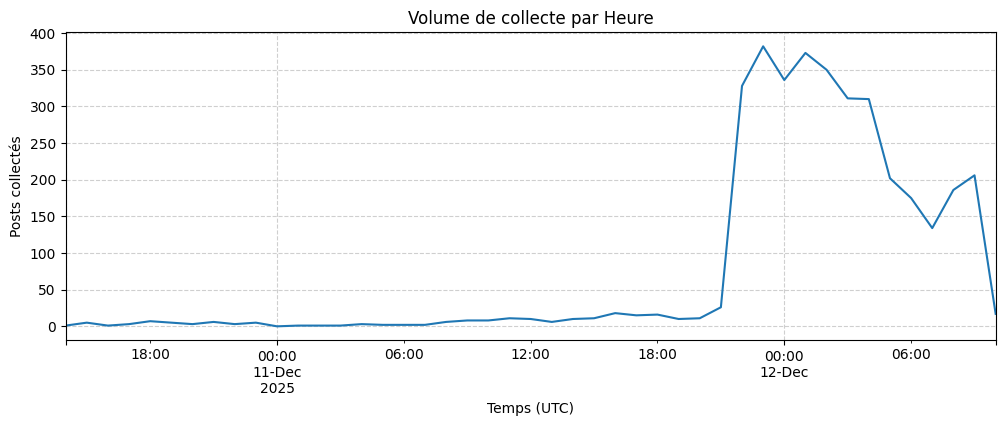

In [2]:
# --- A. Vérification de la qualité des données ---
# Y a-t-il des doublons ?
doublons = df.duplicated(subset=['uri']).sum()
print(f"⚠️ Nombre de doublons potentiels : {doublons}")

# --- B. Distribution par mot-clé ---
# Quels sujets sont les plus populaires dans votre collecte ?
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='search_term', hue='search_term', order=df['search_term'].value_counts().index, palette='viridis', legend=False)
plt.title("Répartition des posts par mot-clé recherché")
plt.xlabel("Thème")
plt.ylabel("Nombre de posts")
plt.show()

# --- C. Analyse Temporelle (Corrigé) ---

# 1. Conversion avec utc=True pour harmoniser les fuseaux horaires
# Cela évite l'erreur "mixed time zones"
df['created_at'] = pd.to_datetime(df['created_at'], format='mixed', utc=True)

# 2. Vérification rapide
print(f"Type de la colonne : {df['created_at'].dtype}")
print(f"Dates valides : {df['created_at'].notna().sum()} / {len(df)}")

# 3. Création du graphique
if df['created_at'].notna().any():
    # On trie par date pour être propre
    df = df.sort_values('created_at')
    
    # On définit l'index et on groupe par heure ('h')
    # kind='timestamp' aide parfois à éviter les bugs d'affichage
    df.set_index('created_at').resample('h').size().plot(
        figsize=(12, 4), 
        title="Volume de collecte par Heure",
        kind='line'
    )
    plt.xlabel("Temps (UTC)")
    plt.ylabel("Posts collectés")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("❌ Aucune date valide.")

In [3]:
import re

# Fonction de nettoyage optimisée
def clean_text_for_ml(text):
    # Sécurité : si le champ est vide ou n'est pas du texte
    if not isinstance(text, str):
        return ""
    
    # 1. Conversion en minuscules (L'IA ne doit pas distinguer "Fake" de "fake")
    text = text.lower()
    
    # 2. Suppression des URLs (souvent du bruit pour l'analyse de sentiment simple)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # 3. Suppression des mentions (@pseudo) et hashtags (#) - Optionnel selon la stratégie
    # Ici on garde les hashtags car ils portent du sens, mais on enlève le '#'
    text = re.sub(r'@\w+', '', text) # Enlève les mentions
    text = re.sub(r'#', '', text)    # Enlève juste le symbole #
    
    # 4. Suppression de la ponctuation et des caractères spéciaux
    text = re.sub(r'[^\w\s]', '', text)
    
    # 5. Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Application sur tout le DataFrame
# On crée une nouvelle colonne pour garder l'original au cas où
df['text_clean'] = df['text'].apply(clean_text_for_ml)

# Comparaison Avant / Après pour vérifier
print("ORIGINAL :", df['text'].iloc[0])
print("NETTOYÉ  :", df['text_clean'].iloc[0])

ORIGINAL : Tu as parlé de flics fascistes et de présidents taulards: c'est du factuel.

Et puis après t'as balancé un complot transphobe colporté par des fafs: c'est pas du factuel.

Alors tes justifications, tu peux te les mettre là où le soleil ne brille pas.
NETTOYÉ  : tu as parlé de flics fascistes et de présidents taulards cest du factuel et puis après tas balancé un complot transphobe colporté par des fafs cest pas du factuel alors tes justifications tu peux te les mettre là où le soleil ne brille pas


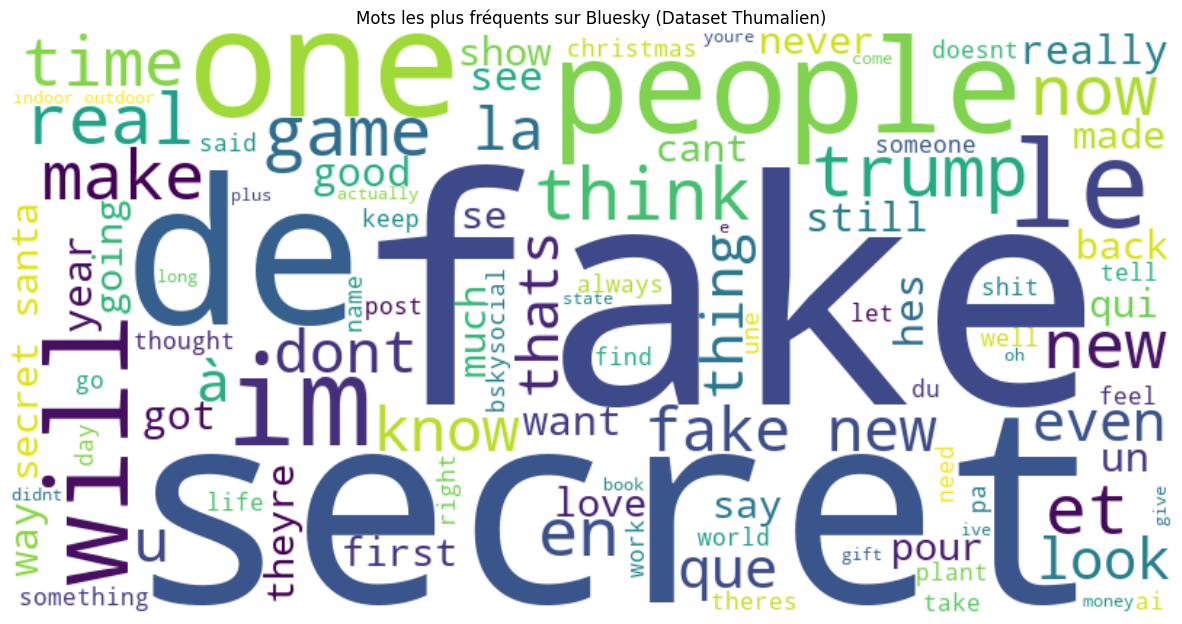

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# On colle tous les textes nettoyés en une seule grande chaîne
all_text = " ".join(text for text in df['text_clean'])

# Création du WordCloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color ='white', 
    colormap='viridis',
    max_words=100
).generate(all_text)

# Affichage
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Mots les plus fréquents sur Bluesky (Dataset Thumalien)")
plt.show()

In [5]:
# Chargement des datasets d'entraînement externes
df_fake = pd.read_csv('../data/training/Fake.csv')
df_true = pd.read_csv('../data/training/True.csv')

# Création de la colonne "label" (C'est la cible que l'IA doit deviner)
# 0 = Vrai, 1 = Fake (Convention classique)
df_fake['label'] = 1
df_true['label'] = 0

# On ne garde que le texte et le label (on simplifie)
df_fake = df_fake[['text', 'label']]
df_true = df_true[['text', 'label']]

# Fusion des deux datasets
df_train = pd.concat([df_fake, df_true], axis=0).reset_index(drop=True)

# Mélange aléatoire (pour ne pas avoir tous les Fake puis tous les Vrais)
df_train = df_train.sample(frac=1).reset_index(drop=True)

print(f"✅ Dataset d'entraînement prêt : {len(df_train)} articles")
print(df_train['label'].value_counts())

✅ Dataset d'entraînement prêt : 44898 articles
label
1    23481
0    21417
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Nettoyage rapide (on réutilise votre fonction clean_text_for_ml si définie plus haut)
# Note: Cela peut prendre 30 sec car il y a beaucoup de texte
print("🧹 Nettoyage des textes en cours...")
df_train['text_clean'] = df_train['text'].apply(lambda x: clean_text_for_ml(str(x)))

# 2. Séparation Entraînement / Test (80% pour apprendre, 20% pour vérifier)
X = df_train['text_clean']
y = df_train['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Vectorisation (Transformation des mots en chiffres)
print("🧮 Vectorisation (TF-IDF)...")
vectorizer = TfidfVectorizer(max_features=5000) # On garde les 5000 mots les plus importants
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Entraînement du modèle (Logistic Regression)
print("🧠 Entraînement du modèle...")
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# 5. Évaluation
y_pred = model.predict(X_test_vec)
print(f"🎯 Précision du modèle : {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Rapport détaillé ---")
print(classification_report(y_test, y_pred))

🧹 Nettoyage des textes en cours...
🧮 Vectorisation (TF-IDF)...
🧠 Entraînement du modèle...
🎯 Précision du modèle : 0.9895

--- Rapport détaillé ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4218
           1       0.99      0.99      0.99      4762

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [7]:
import joblib
import os

# Création du dossier pour stocker les modèles
os.makedirs('../models', exist_ok=True)

# On sauvegarde le Modèle ET le Vectorizer (très important, sinon l'IA ne comprendra pas les nouveaux mots)
joblib.dump(model, '../models/logreg_baseline.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')

print("✅ Modèle et Vectorizer sauvegardés dans le dossier /models")

✅ Modèle et Vectorizer sauvegardés dans le dossier /models


In [8]:
# 1. Récupération des données Bluesky fraîches (depuis Mongo)
cursor = collection.find({}, {"_id": 0})
df_bluesky = pd.DataFrame(list(cursor))

print(f"📡 Analyse de {len(df_bluesky)} posts Bluesky...")

# 2. Nettoyage (Même fonction que pour l'entraînement)
df_bluesky['text_clean'] = df_bluesky['text'].apply(lambda x: clean_text_for_ml(str(x)))

# 3. Vectorisation (On utilise le vectorizer DÉJÀ entraîné)
X_bluesky = vectorizer.transform(df_bluesky['text_clean'])

# 4. Prédictions
# predict() donne 0 ou 1
df_bluesky['prediction_label'] = model.predict(X_bluesky)

# predict_proba() donne la probabilité (ex: 0.85 de chance d'être Fake)
# C'est ce qui servira pour le "Score de crédibilité" demandé par le client
probs = model.predict_proba(X_bluesky)
df_bluesky['fake_probability'] = probs[:, 1] # Probabilité d'être la classe 1 (Fake)

# 5. Traduction pour l'humain
df_bluesky['label_human'] = df_bluesky['prediction_label'].apply(lambda x: "FAKE 🚨" if x == 1 else "VRAI ✅")

# Affichage d'un échantillon aléatoire
display(df_bluesky[['text', 'label_human', 'fake_probability']].sample(10))

📡 Analyse de 3527 posts Bluesky...


,text,label_human,fake_probability
2045,every year people get fake mad over gacha/mobi...,FAKE 🚨,0.625767
940,Secret Santa gift exchange tomorrow! We're sup...,FAKE 🚨,0.835726
2053,Secret Passages #3: An Old School #RPG and Old...,FAKE 🚨,0.903033
1998,Soon it becomes an open to secret to everyone ...,FAKE 🚨,0.825861
886,THE BLOOM TIMES 3ft Spiral Topiary Trees Artif...,FAKE 🚨,0.940908
3391,I barely like doing secret Santa for my family...,FAKE 🚨,0.950592
1625,"Folks, we can do better than a silver spoon dr...",FAKE 🚨,0.934014
2173,Welcome to what I call the Great Unfuckening—t...,FAKE 🚨,0.941270
822,i believe it was genghis khan who said it best...,VRAI ✅,0.409092
146,Los gatos están aliados con las megacorporacio...,FAKE 🚨,0.931406


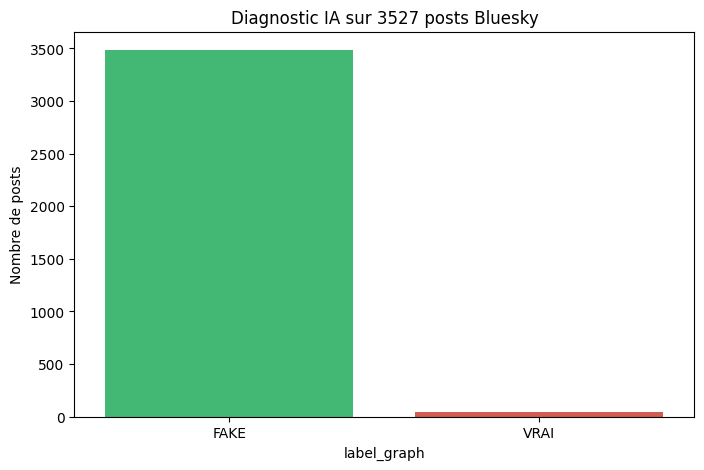

🚨 TOP 5 des posts les plus suspects selon l'IA :
- [1.00] I höst har ett möjligt vaccin mot den dödliga blödarfebern Krim-Kongo testats på Karolinska universi...
- [1.00] (6/6) 👇En 2026, les données seront accessibles aux acteurs publics et scientifiques via DINAMIS et G...
- [1.00] He wishes that this was true. 
Fake it till you make it is his motto....
- [1.00] this terrifies the scammer...
- [1.00] It's truly not secret who and what he is. And if you watch people's circle or conversations you know...


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Création d'une colonne simple pour le graphique (sans émojis qui buggent sur Linux)
df_bluesky['label_graph'] = df_bluesky['prediction_label'].apply(lambda x: "FAKE" if x == 1 else "VRAI")

# 2. Graphique corrigé
plt.figure(figsize=(8, 5))
# Correction : on ajoute hue='label_graph' et legend=False
sns.countplot(data=df_bluesky, x='label_graph', hue='label_graph', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title(f"Diagnostic IA sur {len(df_bluesky)} posts Bluesky")
plt.ylabel("Nombre de posts")
plt.show()

# Affichons les posts jugés les plus "FAKE" (Probabilité proche de 1)
print("🚨 TOP 5 des posts les plus suspects selon l'IA :")
top_fakes = df_bluesky.sort_values(by='fake_probability', ascending=False).head(5)
for index, row in top_fakes.iterrows():
    print(f"- [{row['fake_probability']:.2f}] {row['text'][:100]}...")


In [10]:
from codecarbon import EmissionsTracker

# 1. Initialisation du tracker
# save_to_file=True va créer un fichier 'emissions.csv' à la racine
tracker = EmissionsTracker(project_name="Thumalien_Inference_Baseline", output_dir="../")

print("🔌 Démarrage du monitoring énergétique...")
tracker.start()

# --- DÉBUT DE LA TÂCHE À MESURER ---
# On refait la prédiction pour mesurer son coût
predictions = model.predict(X_bluesky)
# --- FIN DE LA TÂCHE ---

emissions = tracker.stop()
print(f"🛑 Monitoring terminé.")
print(f"🌍 Émissions CO2 : {emissions:.10f} kg")
print(f"⚡ Énergie consommée : {tracker.final_emissions_data.energy_consumed} kWh")

[codecarbon WARNING @ 10:07:54] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 10:07:54] Error while trying to count physical CPUs: invalid literal for int() with base 10: '-'. Defaulting to 1.
[codecarbon INFO @ 10:07:54] [setup] RAM Tracking...
[codecarbon INFO @ 10:07:54] [setup] CPU Tracking...
[codecarbon WARNING @ 10:07:54] We saw that you have a - but we don't know it. Please contact us.
[codecarbon WARNING @ 10:07:54] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:07:54] CPU Model on constant consumption mode: -
[codecarbon WARNING @ 10:07:54] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:07:54] [setup] GPU Tracking...
[codecarbon INFO @ 10:07:54] No GPU found.
[codecarbon INFO @ 10:07:54] The below tracking methods

🔌 Démarrage du monitoring énergétique...
🛑 Monitoring terminé.
🌍 Émissions CO2 : 0.0000000028 kg
⚡ Énergie consommée : 5.06105976667944e-08 kWh


In [11]:
from pymongo import UpdateOne

print("💾 Sauvegarde des scores dans MongoDB...")

# On prépare une liste d'opérations en masse (Bulk Write) pour aller vite
operations = []

for index, row in df_bluesky.iterrows():
    # On définit la mise à jour pour ce post précis (identifié par son URI)
    operation = UpdateOne(
        {"uri": row['uri']},  # Filtre : trouve le post avec cette URI
        {"$set": {            # Action : Ajoute/Modifie ces champs
            "ai_score_credibility": float(1 - row['fake_probability']), # Score de fiabilité (inverse du fake)
            "ai_label": int(row['prediction_label']),
            "ai_processed_at": pd.Timestamp.now()
        }}
    )
    operations.append(operation)

# Exécution si on a des données
if operations:
    result = collection.bulk_write(operations)
    print(f"✅ {result.modified_count} posts mis à jour avec le score IA dans MongoDB.")
else:
    print("⚠️ Rien à sauvegarder.")

💾 Sauvegarde des scores dans MongoDB...
✅ 3527 posts mis à jour avec le score IA dans MongoDB.
